# Circuit-Level Decoder Comparison

This notebook loads the raw cluster summary CSV for the `bicycle_bivariate_144_12_12_memory_Z` Z-basis run, assigns decoder numbers from first appearance order in the file, and lets you quickly plot only the decoders you want.

Workflow:
- edit `selected_decoder_indices` in the config cell
- optionally edit `selected_p_values`
- run the notebook top to bottom
- use the numbered decoder table to pick the curves you want


In [13]:
import json
from pathlib import Path

from IPython import get_ipython
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

_ip = get_ipython()
if _ip is not None:
    try:
        _ip.run_line_magic("matplotlib", "inline")
    except Exception:
        pass

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 200)
np.set_printoptions(edgeitems=20, linewidth=160, suppress=True)


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "tests" / "testdata" / "bicycle_bivariate").exists():
            return candidate
    raise FileNotFoundError(
        "Could not find repo root containing tests/testdata/bicycle_bivariate "
        f"starting from {start}."
    )


repo_root = find_repo_root(Path.cwd().resolve())

# Edit these values.
summary_csv_path = repo_root / "bicycle_bivariate_144_12_12_native_bpgd_cluster_Z_basis_summary.csv"
selected_decoder_indices = [1, 2, 3, 6, 10, 11 12, 14, 16, 18, 19]
selected_p_values = None  # e.g. [0.001, 0.003, 0.005]
plot_title = None


SyntaxError: invalid syntax. Perhaps you forgot a comma? (451570611.py, line 36)

In [14]:
def load_cluster_summary(path: Path) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    if not path.exists():
        raise FileNotFoundError(f"Summary CSV not found: {path}")

    raw_df = pd.read_csv(path, skipinitialspace=True)
    raw_df.columns = [str(col).strip() for col in raw_df.columns]

    required_columns = {"shots", "errors", "seconds", "decoder", "json_metadata"}
    missing_columns = sorted(required_columns - set(raw_df.columns))
    if missing_columns:
        raise ValueError(f"Summary CSV is missing required columns: {missing_columns}")

    raw_df["shots"] = pd.to_numeric(raw_df["shots"], errors="raise")
    raw_df["errors"] = pd.to_numeric(raw_df["errors"], errors="raise")
    raw_df["seconds"] = pd.to_numeric(raw_df["seconds"], errors="raise")
    raw_df["decoder"] = raw_df["decoder"].astype(str)

    metadata_list = raw_df["json_metadata"].map(lambda text: json.loads(str(text)))
    raw_df["p"] = metadata_list.map(lambda meta: float(meta["p"]))
    raw_df["circuit"] = metadata_list.map(lambda meta: str(meta.get("circuit", "unknown")))
    raw_df["basis_filter_applied"] = metadata_list.map(
        lambda meta: str(meta.get("basis_filter_applied", "none"))
    )

    decoder_names = raw_df["decoder"].drop_duplicates().tolist()
    decoder_index_df = pd.DataFrame(
        {
            "decoder_index": np.arange(1, len(decoder_names) + 1, dtype=int),
            "decoder": decoder_names,
        }
    )
    decoder_to_index = dict(zip(decoder_index_df["decoder"], decoder_index_df["decoder_index"]))

    summary_df = (
        raw_df.groupby(["decoder", "p"], as_index=False)
        .agg(shots=("shots", "sum"), errors=("errors", "sum"), seconds=("seconds", "sum"))
    )
    summary_df["decoder_index"] = summary_df["decoder"].map(decoder_to_index).astype(int)
    summary_df["ler"] = summary_df["errors"] / summary_df["shots"]
    summary_df["stderr"] = (
        (summary_df["ler"] * (1.0 - summary_df["ler"]) / summary_df["shots"]).clip(lower=0.0)
    ) ** 0.5
    summary_df = summary_df.sort_values(["decoder_index", "p"]).reset_index(drop=True)

    return raw_df, decoder_index_df, summary_df


raw_summary_df, decoder_index_df, summary_df = load_cluster_summary(summary_csv_path)
available_p_values = sorted(summary_df["p"].unique().tolist())

setup_df = pd.DataFrame(
    [
        {
            "summary_csv_path": str(summary_csv_path),
            "n_raw_rows": int(len(raw_summary_df)),
            "n_decoders": int(len(decoder_index_df)),
            "p_values": available_p_values,
            "circuits": sorted(raw_summary_df["circuit"].dropna().unique().tolist()),
            "basis_filters": sorted(raw_summary_df["basis_filter_applied"].dropna().unique().tolist()),
        }
    ]
)

display(setup_df)
display(summary_df.head(10))


,summary_csv_path,n_raw_rows,n_decoders,p_values,circuits,basis_filters
0,C:\Users\User\Documents\projects-git\relay_mother_folder\relay\bicycle_bivariate_144_12_12_native_bpgd_cluster_Z_basis_summary.csv,115,23,"[0.001, 0.002, 0.003, 0.004, 0.005]",[bicycle_bivariate_144_12_12_memory_Z],[Z]


,decoder,p,shots,errors,seconds,decoder_index,ler,stderr
0,msl-bp,0.001,17336,28,51.90,1,0.001615,0.000305
1,msl-bp,0.002,6197,132,38.30,1,0.021301,0.001834
2,msl-bp,0.003,878,76,14.40,1,0.086560,0.009490
3,msl-bp,0.004,112,42,6.08,1,0.375000,0.045745
4,msl-bp,0.005,156,88,8.12,1,0.564103,0.039702
5,msl-bp-damp0p5,0.001,19329,18,21.70,2,0.000931,0.000219
6,msl-bp-damp0p5,0.002,7157,51,19.00,2,0.007126,0.000994
7,msl-bp-damp0p5,0.003,1870,81,14.10,2,0.043316,0.004707
8,msl-bp-damp0p5,0.004,1050,149,15.80,2,0.141905,0.010769
9,msl-bp-damp0p5,0.005,362,134,10.60,2,0.370166,0.025378


## Decoder Numbers

Decoder numbers come from first appearance order in the loaded CSV.
Change `selected_decoder_indices` in the config cell using this table.


In [15]:
def normalize_selected_decoder_indices(values: list[int], max_decoder_index: int) -> list[int]:
    normalized = []
    seen = set()
    for value in values:
        index = int(value)
        if index in seen:
            continue
        seen.add(index)
        normalized.append(index)

    if not normalized:
        raise ValueError(
            "selected_decoder_indices is empty. Pick one or more decoder numbers from the table above."
        )

    invalid = [index for index in normalized if index < 1 or index > max_decoder_index]
    if invalid:
        raise ValueError(
            f"Invalid decoder indices {invalid}. Valid indices are 1..{max_decoder_index}."
        )

    return normalized


display(decoder_index_df)

selected_decoder_indices = normalize_selected_decoder_indices(
    selected_decoder_indices,
    int(decoder_index_df["decoder_index"].max()),
)
selected_decoders = (
    decoder_index_df.set_index("decoder_index").loc[selected_decoder_indices, "decoder"].tolist()
)

selected_decoder_table = decoder_index_df[
    decoder_index_df["decoder_index"].isin(selected_decoder_indices)
].copy()
selected_decoder_table["decoder_index"] = pd.Categorical(
    selected_decoder_table["decoder_index"],
    categories=selected_decoder_indices,
    ordered=True,
)
selected_decoder_table = (
    selected_decoder_table.sort_values("decoder_index").reset_index(drop=True)
)
selected_decoder_table["decoder_index"] = selected_decoder_table["decoder_index"].astype(int)

display(selected_decoder_table)
print("selected_decoder_indices =", selected_decoder_indices)
print("selected_decoders =", selected_decoders)


,decoder_index,decoder
0,1,msl-bp
1,2,msl-bp-damp0p5
2,3,bpgd-low-only
3,4,msl-bp-1000iter
4,5,msl-bp-damp0p5-1000iter
5,6,bpgd-high-init0p99
6,7,bpgd-high-init0p98
7,8,msl-bp-damp0p75
8,9,msl-bp-damp0p75-1000iter
9,10,msl-bp-10k


,decoder_index,decoder
0,1,msl-bp
1,2,msl-bp-damp0p5
2,3,bpgd-low-only
3,10,msl-bp-10k
4,12,relay-bp-30sets
5,14,relayed-bpgd-30sets
6,16,relay-bp-300sets
7,18,relay-bp-30sets-independent
8,19,relayed-bpgd-30sets-independent


selected_decoder_indices = [1, 2, 3, 10, 12, 14, 16, 18, 19]
selected_decoders = ['msl-bp', 'msl-bp-damp0p5', 'bpgd-low-only', 'msl-bp-10k', 'relay-bp-30sets', 'relayed-bpgd-30sets', 'relay-bp-300sets', 'relay-bp-30sets-independent', 'relayed-bpgd-30sets-independent']


## Plot Selected Decoders

This cell filters the aggregated summary to the selected decoder numbers and optionally to a subset of `p` values.


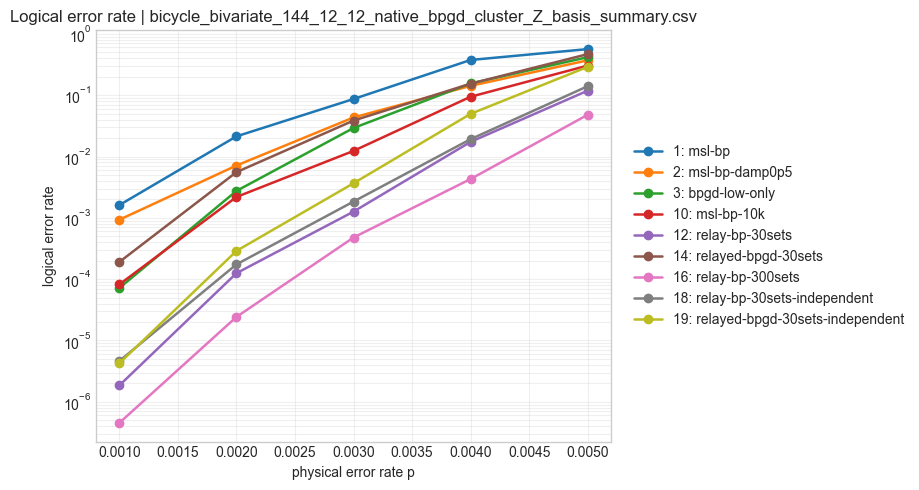

,decoder_index,decoder,p,shots,errors,ler,stderr,seconds
0,1,msl-bp,0.001,17336,28,1.615136e-03,3.049854e-04,51.90
1,1,msl-bp,0.002,6197,132,2.130063e-02,1.834130e-03,38.30
2,1,msl-bp,0.003,878,76,8.656036e-02,9.489694e-03,14.40
3,1,msl-bp,0.004,112,42,3.750000e-01,4.574532e-02,6.08
4,1,msl-bp,0.005,156,88,5.641026e-01,3.970168e-02,8.12
5,2,msl-bp-damp0p5,0.001,19329,18,9.312432e-04,2.193939e-04,21.70
6,2,msl-bp-damp0p5,0.002,7157,51,7.125891e-03,9.942627e-04,19.00
7,2,msl-bp-damp0p5,0.003,1870,81,4.331551e-02,4.707445e-03,14.10
8,2,msl-bp-damp0p5,0.004,1050,149,1.419048e-01,1.076891e-02,15.80
9,2,msl-bp-damp0p5,0.005,362,134,3.701657e-01,2.537798e-02,10.60


In [16]:
def normalize_selected_p_values(values: list[float] | None) -> list[float] | None:
    if values is None:
        return None

    normalized = []
    seen = set()
    for value in values:
        p = float(value)
        if p in seen:
            continue
        seen.add(p)
        normalized.append(p)
    return normalized


def build_filtered_summary(
    summary_df: pd.DataFrame,
    selected_decoders: list[str],
    selected_p_values: list[float] | None,
) -> pd.DataFrame:
    filtered_df = summary_df[summary_df["decoder"].isin(selected_decoders)].copy()
    if selected_p_values is not None:
        filtered_df = filtered_df[filtered_df["p"].isin(selected_p_values)].copy()

    filtered_df["decoder"] = pd.Categorical(
        filtered_df["decoder"],
        categories=selected_decoders,
        ordered=True,
    )
    filtered_df = filtered_df.sort_values(["decoder", "p"]).reset_index(drop=True)
    filtered_df["decoder"] = filtered_df["decoder"].astype(str)
    return filtered_df


normalized_p_values = normalize_selected_p_values(selected_p_values)
if normalized_p_values is not None:
    missing_p_values = [p for p in normalized_p_values if p not in available_p_values]
    if missing_p_values:
        raise ValueError(
            f"selected_p_values contains values not present in the CSV: {missing_p_values}. "
            f"Available values are {available_p_values}."
        )

filtered_summary_df = build_filtered_summary(
    summary_df,
    selected_decoders,
    normalized_p_values,
)
if filtered_summary_df.empty:
    raise ValueError("No rows remain after applying the current decoder and p filters.")

fig, ax = plt.subplots(figsize=(9, 5))
for decoder_index, decoder_name in zip(selected_decoder_indices, selected_decoders):
    group = filtered_summary_df[filtered_summary_df["decoder"] == decoder_name].sort_values("p")
    ax.plot(
        group["p"],
        group["ler"],
        marker="o",
        linewidth=1.8,
        label=f"{decoder_index}: {decoder_name}",
    )

ax.set_title(plot_title or f"Logical error rate | {summary_csv_path.name}")
ax.set_xlabel("physical error rate p")
ax.set_ylabel("logical error rate")
ax.set_yscale("log")
ax.grid(True, which="both", alpha=0.3)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
fig.tight_layout()
plt.show()

display(
    filtered_summary_df[
        ["decoder_index", "decoder", "p", "shots", "errors", "ler", "stderr", "seconds"]
    ]
)
